In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [13]:
df = pd.read_csv('bank-full[1].csv',sep =';')

In [15]:
print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

Shape: (45211, 17)

First 5 rows:
    age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing Values:
age          0
job          0
marital      0
education    0
de

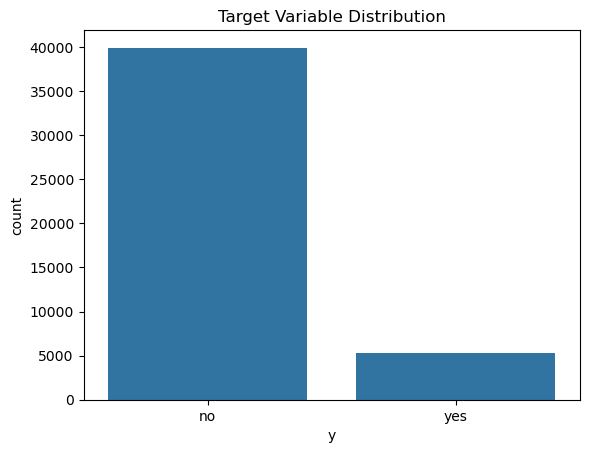


Numerical Summary:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%    

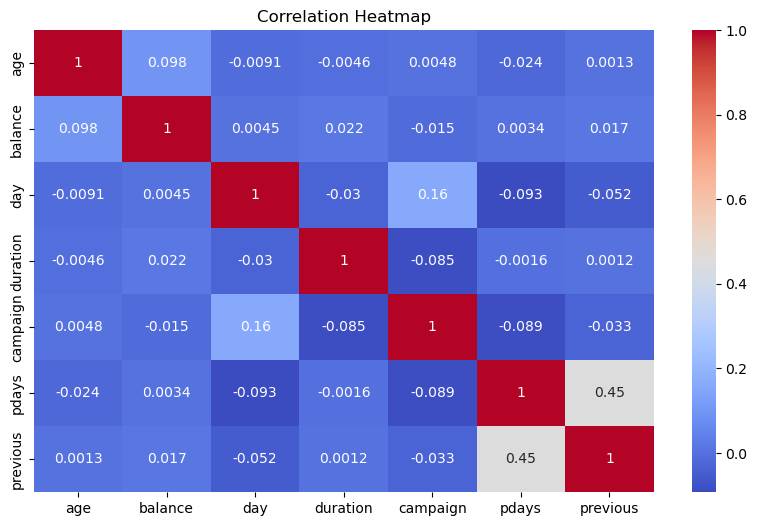

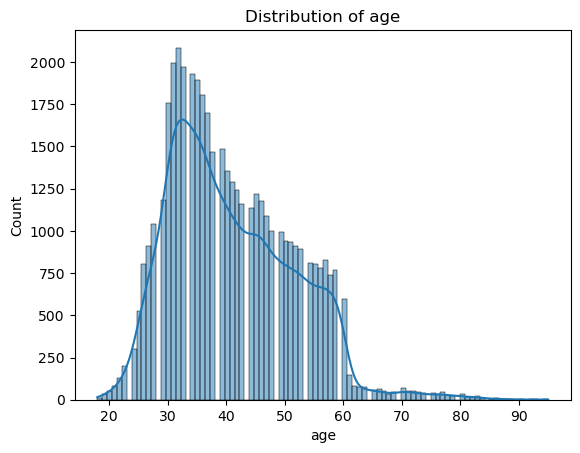

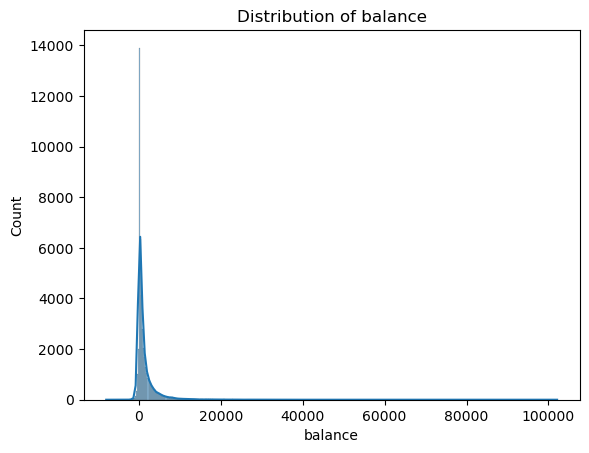

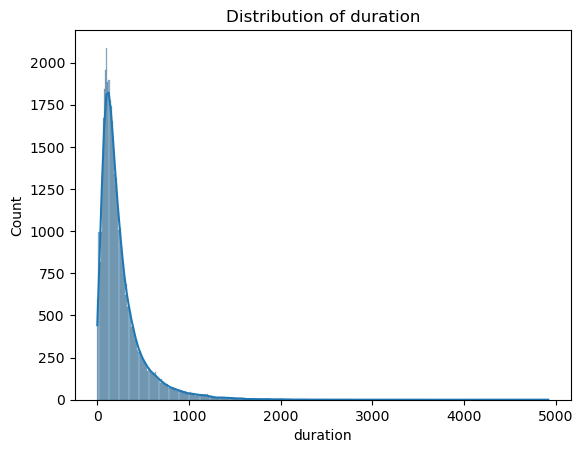

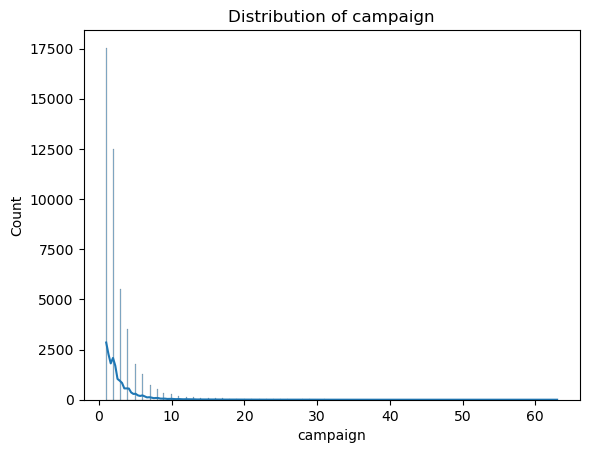

In [16]:
# Info & Null Check
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Target distribution
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

# Numerical summary
print("\nNumerical Summary:")
print(df.describe())

# Correlation heatmap (only numeric)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Example distributions
num_cols = ['age', 'balance', 'duration', 'campaign']
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [18]:
# Convert target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Label Encoding for categorical features
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nEncoded Data Sample:\n", df.head())


Encoded Data Sample:
    age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome   y  
0    5      8       261         1     -1         0         3 NaN  
1    5      8       151         1     -1         0         3 NaN  
2    5      8        76         1     -1         0         3 NaN  
3    5      8        92         1     -1         0         3 NaN  
4    5      8       198         1     -1         0         3 NaN  


In [25]:
X = df_final.drop('y_yes', axis=1)
y = df_final['y_yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
# Logistic Regression
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {model_name} =====")
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


===== Logistic Regression =====
F1 Score: 0.45248313917841815

Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.97      0.95      7985
        True       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



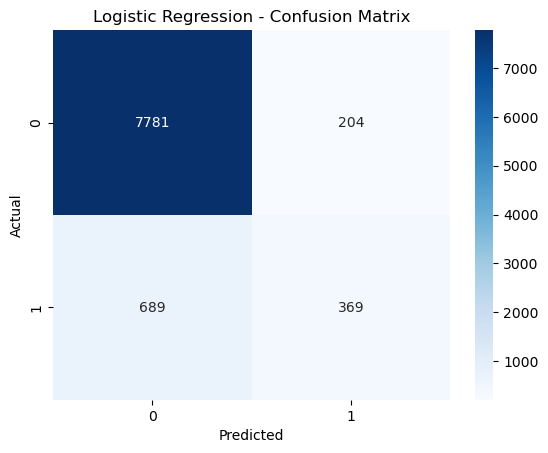

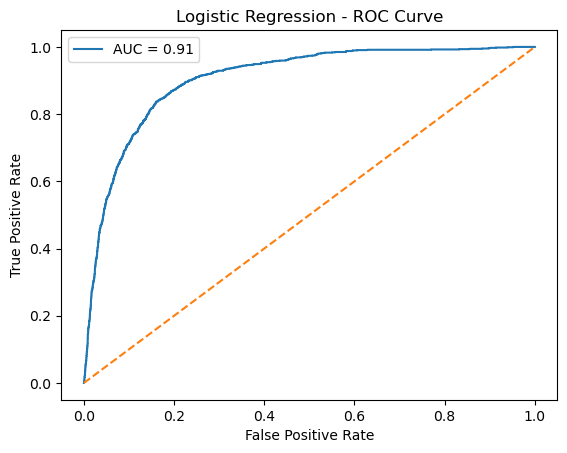


===== Random Forest =====
F1 Score: 0.48931116389548696

Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.97      0.95      7985
        True       0.66      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



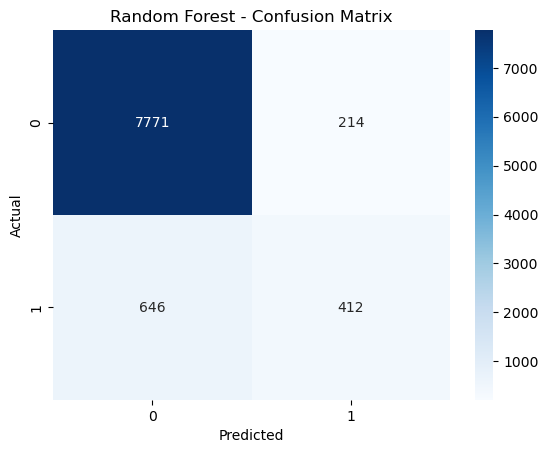

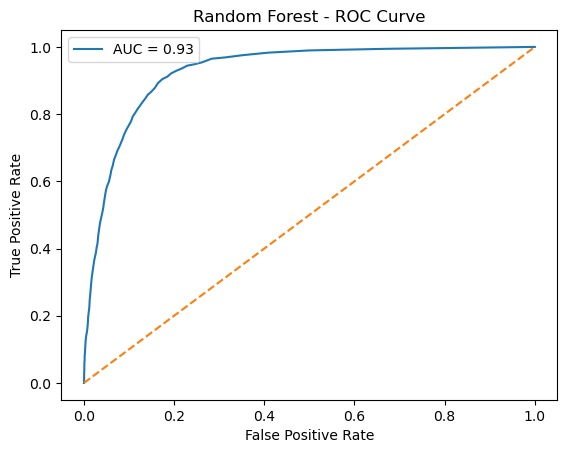

In [28]:
evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(rf, X_test, y_test, "Random Forest")

In [29]:
!pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283917 sha256=0db15756f41a836b8a9f2366360f7b5c8bcf373eca89af26eb56ece6761c93e2
  Stored in directory: c:\users\sg\appdata\local\pip\cache\wheels\7c\04\5c\157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [30]:
import warnings
warnings.filterwarnings('ignore')

from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['No', 'Yes'],
    mode='classification'
)

for i in range(5):
    print(f"\nExplanation for sample {i}")
    
    exp = explainer.explain_instance(
        X_test.iloc[i].values,
        lambda x: rf.predict_proba(pd.DataFrame(x, columns=X.columns))
    )
    
    print(exp.as_list())


Explanation for sample 0
[('duration > 318.00', 0.2607090260294772), ('month_mar <= 0.00', -0.18216984177459603), ('month_oct <= 0.00', -0.12353893117779227), ('poutcome_success <= 0.00', -0.108902331900903), ('month_sep <= 0.00', -0.10256001399193461), ('month_dec <= 0.00', -0.08974549271385245), ('month_jun <= 0.00', -0.07151994847989836), ('month_feb <= 0.00', -0.05503567543118657), ('0.00 < contact_unknown <= 1.00', -0.042615777640050694), ('0.00 < housing_yes <= 1.00', -0.033809196103202044)]

Explanation for sample 1
[('month_mar <= 0.00', -0.1882843835699289), ('month_dec <= 0.00', -0.12861318928164145), ('month_oct <= 0.00', -0.10627085891907902), ('poutcome_success <= 0.00', -0.09778383699986161), ('month_sep <= 0.00', -0.0939625023475613), ('month_jun <= 0.00', -0.07503245198603473), ('month_feb <= 0.00', -0.055628129550218536), ('previous <= 0.00', -0.03945210449872792), ('0.00 < housing_yes <= 1.00', -0.03563917522925521), ('0.00 < contact_unknown <= 1.00', -0.035408901456